# Demo: reading a published per-lake NetCDF

This notebook opens `CW2019_1907.nc`, one of the 1,679 per-lake CF-1.8
NetCDF files in the ESSD-companion **Central West Greenland Supraglacial
Lake Drainage Classification Dataset (2018-2019)** (Rines et al., 2026,
[doi:10.25740/sf350xp4038](https://doi.org/10.25740/sf350xp4038)).

The file is bundled with this repo at `demos/CW2019_1907.nc` so the
notebook runs offline. It demonstrates the full schema produced by
`sat-tile-stack`'s build pipeline: imagery + cloud mask + NDWI water
mask + static lake boundary + scalar `p_water` series + the embedded
expert drainage-mechanism label.

In [2]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

NC_PATH = Path(__file__).parent / 'CW2019_1907.nc' if '__file__' in globals() else Path('CW2019_1907.nc')
ds = xr.open_dataset(NC_PATH)
print(f'opened {NC_PATH.name}')
print(f'  dims:   {dict(ds.sizes)}')
print(f'  vars:   {list(ds.data_vars)}')
print(f'  CF:     Conventions={ds.attrs.get("Conventions","?")}')


opened CW2019_1907.nc
  dims:   {'time': 153, 'band': 6, 'y': 512, 'x': 512, 'class': 5}
  vars:   ['reflectance', 'cloud_mask', 'crs', 'p_water', 'lake_boundary', 'water_mask_ndwi', 'label_probability', 'drainage_label']
  CF:     Conventions=CF-1.8


## The expert label

The drainage mechanism label is embedded as a CF flag variable
(`drainage_label`) plus a 5-class soft probability vector
(`label_probability`). The class names live on the `class_name`
coordinate.

In [3]:
class_names = [bytes(c).decode().strip() for c in ds.class_name.values]
hard_idx    = int(ds.drainage_label.values)
soft        = ds.label_probability.values

print(f'class names:        {class_names}')
print(f'hard label:         {class_names[hard_idx]}  (CF flag value {hard_idx})')
print(f'soft probabilities: {dict(zip(class_names, [float(p) for p in soft]))}')
print(f'\nfree-text attrs')
for k in ('drainage_label', 'drainage_notes', 'label_flagged', 'label_source'):
    if k in ds.attrs:
        print(f'  {k}: {ds.attrs[k]}')


class names:        ['ND', 'HF', 'MD', 'LD', 'CD']
hard label:         LD  (CF flag value 3)
soft probabilities: {'ND': 0.0, 'HF': 0.0, 'MD': 0.0, 'LD': 1.0, 'CD': 0.0}

free-text attrs
  drainage_label: LD
  drainage_notes: 
  label_flagged: 0
  label_source: manual 5-class drainage labeling, lead author (Rines et al., Sect. 2.4); inter-rater labels in sidecar CSV


## DN → surface reflectance

`reflectance` is stored as raw Sentinel-2 L2A digital numbers cast to
float32. Convert to surface reflectance with the per-scene additive
offset and the dataset-level quantification value:

$$\rho = \frac{\text{DN} + \text{boa\_add\_offset}}{\text{s2\_quantification\_value}}$$

In [4]:
Q      = ds.attrs['s2_quantification_value']             # 10000
offset = ds['boa_add_offset']                            # (time,) float
rho    = (ds['reflectance'] + offset) / Q                # (time, band, y, x)

print(f's2_quantification_value = {Q}')
print(f'unique boa_add_offset values in this file: {np.unique(offset.values)}')
print(f'reflectance band order: {list(ds.band_name.values)}')   # RGB-first


s2_quantification_value = 10000
unique boa_add_offset values in this file: [ 0. nan]
reflectance band order: ['B04', 'B03', 'B02', 'B08', 'B11', 'B12']


## Render one clear RGB frame, with the static lake boundary

We pick the timestep with the lowest cloud cover, build a true-color
RGB image from the (B04, B03, B02) bands, and overlay both the static
`lake_boundary` (from the Dunmire 2021 catalog, rasterized to the
per-lake grid by `coregister.add_static_polygon`) and the dynamic
`water_mask_ndwi` (NDWI > 0.3 derived from each scene by
`coregister.add_ndwi_from_stack`).

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1628..1.2008].


clearest timestep: 2019-05-14  (eo_cloud_cover=0.0%)


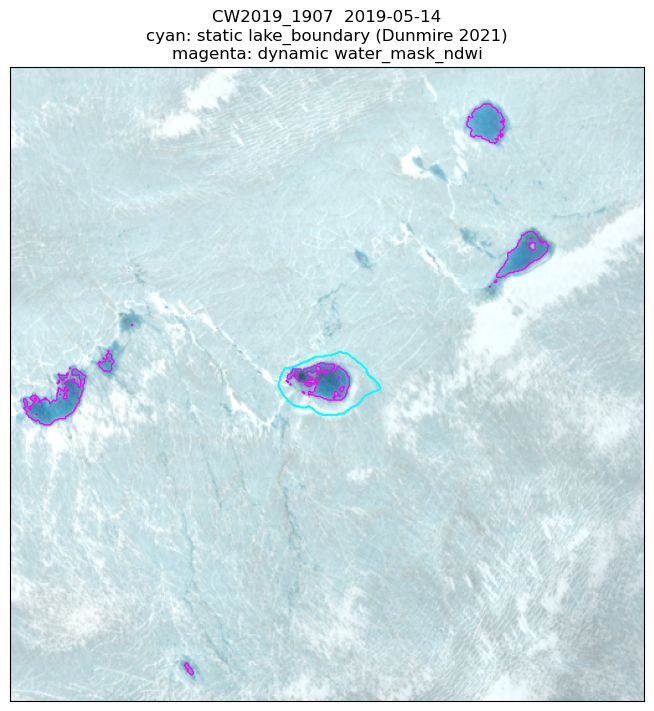

In [ ]:
cc      = ds['eo_cloud_cover'].values
t_clear = int(np.nanargmin(cc))
print(f'clearest timestep: {str(ds.time.values[t_clear])[:10]}  '
      f'(eo_cloud_cover={cc[t_clear]:.1f}%)')

bnames = list(ds.band_name.values)
ri, gi, bi = (bnames.index(b) for b in ('B04', 'B03', 'B02'))

rgb = np.stack([rho.isel(time=t_clear, band=i).values for i in (ri, gi, bi)], axis=-1)

fig, ax = plt.subplots(1, 1, figsize=(7, 7), constrained_layout=True)
ax.imshow(rgb)
ax.contour(ds['lake_boundary'].values, levels=[0.5], colors='cyan', linewidths=1.5)
ndwi = ds['water_mask_ndwi'].isel(time=t_clear).values
ax.contour(np.nan_to_num(ndwi, nan=0.0), levels=[0.5], colors='magenta', linewidths=1.0)
ax.set_title(f"CW2019_1907  {str(ds.time.values[t_clear])[:10]}\n"
             f"cyan: static lake_boundary (Dunmire 2021)\n"
             f"magenta: dynamic water_mask_ndwi")
ax.set_xticks([]); ax.set_yticks([])
plt.show()


## The `p_water` scalar series

The daily fractional water surface-area `p_water(time)` comes from
Dunmire et al. (2025), re-aligned to each lake's time axis by
`coregister.add_scalar_series`. It's the second-stream input to the
ESSD baseline classifier alongside the imagery branch.

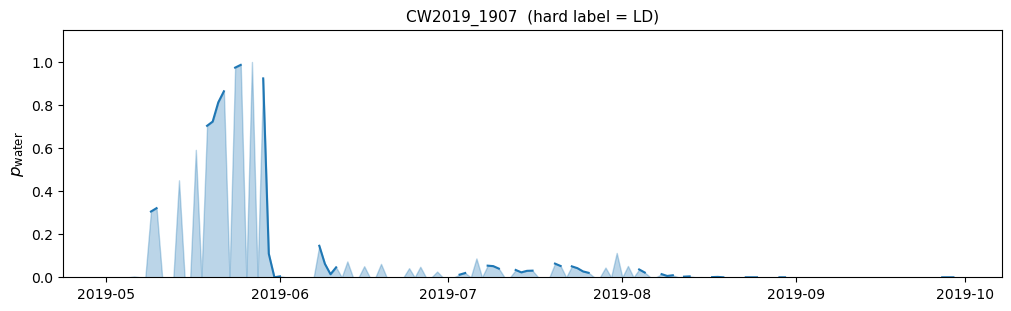

In [6]:
pw = ds['p_water'].values
fig, ax = plt.subplots(1, 1, figsize=(10, 3), constrained_layout=True)
ax.fill_between(ds.time.values, 0, np.nan_to_num(pw, nan=0.0), alpha=0.3, color='C0')
ax.plot(ds.time.values, pw, color='C0', lw=1.5)
ax.set_ylabel(r'$p_{\mathrm{water}}$', fontsize=12)
ax.set_ylim(0, max(0.3, np.nanmax(pw) * 1.15))
ax.set_title(f"CW2019_1907  (hard label = {class_names[hard_idx]})", fontsize=11)
plt.show()

ds.close()
